In [2]:
import torch
print(torch.__version__)

2.7.1+cpu


In [3]:
# 初始化一个简单的tensor
a = torch.tensor([1, 2, 3])
print("初始化的tensor a:", a)

# ndarray转tensor
import numpy as np
arr = np.array([[1, 2], [3, 4]])
tensor_from_np = torch.from_numpy(arr)
print("由ndarray转成的tensor:", tensor_from_np)

# tensor变ndarray
ndarray_from_tensor = tensor_from_np.numpy()
print("由tensor转成的ndarray:", ndarray_from_tensor)

初始化的tensor a: tensor([1, 2, 3])
由ndarray转成的tensor: tensor([[1, 2],
        [3, 4]], dtype=torch.int32)
由tensor转成的ndarray: [[1 2]
 [3 4]]


In [4]:
t1=torch.Tensor(2,3)
t1

tensor([[0., 0., 0.],
        [0., 0., 0.]])

## 初始化分布

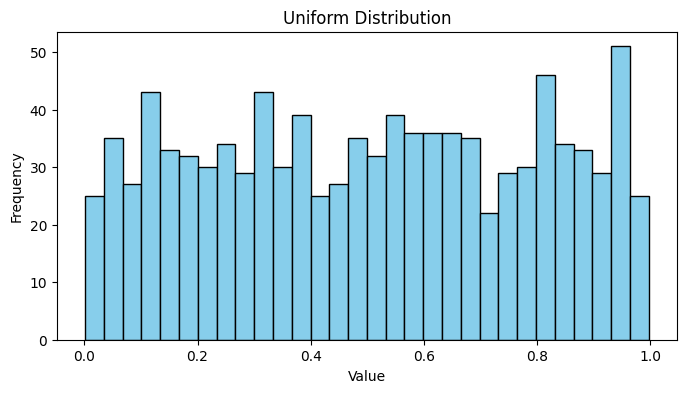

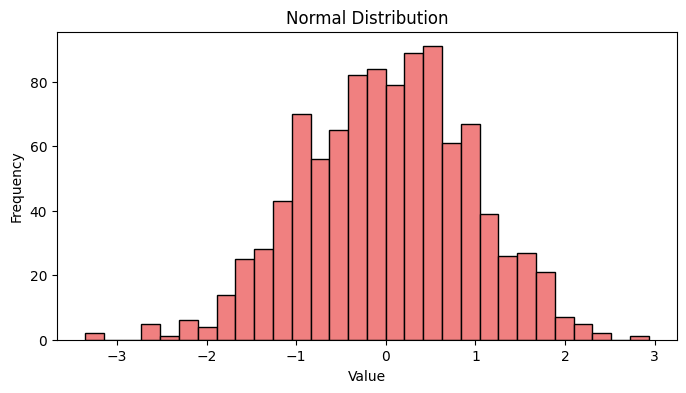

In [5]:
import matplotlib.pyplot as plt

# 创建均匀分布的张量
uniform_tensor = torch.rand(1000)
plt.figure(figsize=(8, 4))
plt.hist(uniform_tensor.numpy(), bins=30, color='skyblue', edgecolor='black')
plt.title('Uniform Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# 创建正态分布的张量
normal_tensor = torch.randn(1000)
plt.figure(figsize=(8, 4))
plt.hist(normal_tensor.numpy(), bins=30, color='lightcoral', edgecolor='black')
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [6]:
# 张量类型转换演示

# 创建一个整型的张量
int_tensor = torch.tensor([1, 2, 3, 4], dtype=torch.int32)
print("原始整型张量:", int_tensor, "dtype:", int_tensor.dtype)

# 转换为浮点型
float_tensor = int_tensor.float()
print("转换为float后的张量:", float_tensor, "dtype:", float_tensor.dtype)

# 转换为双精度浮点型
double_tensor = int_tensor.double()
print("转换为double后的张量:", double_tensor, "dtype:", double_tensor.dtype)

# 转换为长整型
long_tensor = float_tensor.long()
print("float张量转换为long:", long_tensor, "dtype:", long_tensor.dtype)

# 也可以使用to()方法进行类型转换
to_tensor = int_tensor.to(torch.float16)
print("to()方法转换为float16:", to_tensor, "dtype:", to_tensor.dtype)

原始整型张量: tensor([1, 2, 3, 4], dtype=torch.int32) dtype: torch.int32
转换为float后的张量: tensor([1., 2., 3., 4.]) dtype: torch.float32
转换为double后的张量: tensor([1., 2., 3., 4.], dtype=torch.float64) dtype: torch.float64
float张量转换为long: tensor([1, 2, 3, 4]) dtype: torch.int64
to()方法转换为float16: tensor([1., 2., 3., 4.], dtype=torch.float16) dtype: torch.float16


# 加减乘除

In [7]:
# 演示 add_ 等操作（带下划线的原地操作）

a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([0.5, 0.5, 0.5])

print("原始 a:", a)

# 使用普通加法不会改变原数据
c = a + b
print("a + b =", c)
print("a（未改变）:", a)

# 使用原地加法 add_
a.add_(b)
print("a.add_(b) 后，a 变为:", a)

# 再演示其它原地操作
d = torch.tensor([2.0, 2.0, 2.0])

print("\n另一个张量 d:", d)

# 原地乘法 mul_
d.mul_(2)
print("d.mul_(2) 后 d:", d)

# 原地减法 sub_
d.sub_(1)
print("d.sub_(1) 后 d:", d)

# 原地除法 div_
d.div_(3)
print("d.div_(3) 后 d:", d)

原始 a: tensor([1., 2., 3.])
a + b = tensor([1.5000, 2.5000, 3.5000])
a（未改变）: tensor([1., 2., 3.])
a.add_(b) 后，a 变为: tensor([1.5000, 2.5000, 3.5000])

另一个张量 d: tensor([2., 2., 2.])
d.mul_(2) 后 d: tensor([4., 4., 4.])
d.sub_(1) 后 d: tensor([3., 3., 3.])
d.div_(3) 后 d: tensor([1., 1., 1.])


# 矩阵乘法

In [8]:
a = torch.randint(0, 10, (2, 3))
b = torch.randint(0, 10, (3, 2))

print("矩阵 a:\n", a)
print("矩阵 b:\n", b)

# 方式1: 使用 @ 操作符
result1 = a @ b
print("a @ b =\n", result1)

# 方式2: 使用 matmul 函数
result2 = torch.matmul(a, b)
print("torch.matmul(a, b) =\n", result2)

# 方式3: 使用 mm 函数（仅限于二维）
result3 = torch.mm(a, b)
print("torch.mm(a, b) =\n", result3)



矩阵 a:
 tensor([[2, 5, 3],
        [0, 5, 6]])
矩阵 b:
 tensor([[5, 7],
        [0, 7],
        [2, 0]])
a @ b =
 tensor([[16, 49],
        [12, 35]])
torch.matmul(a, b) =
 tensor([[16, 49],
        [12, 35]])
torch.mm(a, b) =
 tensor([[16, 49],
        [12, 35]])


# 形状操作

In [9]:
# 初始化一个 shape 为 (2,3,4) 的张量
tensor = torch.randn(2, 3, 4)
print("原始张量 shape:", tensor.shape)


# 使用 permute 交换轴, 例如交换第0和第1个轴 (变为(3,2,4))
permuted_tensor = tensor.permute(0, 2, 1)
print("permute(1, 0, 2) 后的 shape:", permuted_tensor.shape)

原始张量 shape: torch.Size([2, 3, 4])
permute(1, 0, 2) 后的 shape: torch.Size([2, 4, 3])


In [10]:
# 增加一个维度（unsqueeze）
x = torch.tensor([1, 2, 3])
print("原始张量:", x)
print("原始 shape:", x.shape)

x_unsqueezed = x.unsqueeze(0)  # 在第0维增加一个维度
print("unsqueeze(0) 后:", x_unsqueezed)
print("unsqueeze(0) 后的 shape:", x_unsqueezed.shape)



原始张量: tensor([1, 2, 3])
原始 shape: torch.Size([3])
unsqueeze(0) 后: tensor([[1, 2, 3]])
unsqueeze(0) 后的 shape: torch.Size([1, 3])


In [11]:
x_unsqueezed = x.unsqueeze(1)  # 在第1维增加一个维度
print("unsqueeze(1) 后:", x_unsqueezed)
print("unsqueeze(1) 后的 shape:", x_unsqueezed.shape)

unsqueeze(1) 后: tensor([[1],
        [2],
        [3]])
unsqueeze(1) 后的 shape: torch.Size([3, 1])


In [12]:
# 删除一个维度（squeeze）
y = torch.zeros(1, 3, 1, 5)
print("\n带有多余维度的张量 shape:", y.shape)
y_squeezed = y.squeeze()  # 删除所有大小为1的维度
print("squeeze() 后的 shape:", y_squeezed.shape)

# 也可以只删除指定的维度
y_squeezed_dim2 = y.squeeze(2)  # 只删除第2维（若其大小为1）
print("squeeze(2) 后的 shape:", y_squeezed_dim2.shape)


带有多余维度的张量 shape: torch.Size([1, 3, 1, 5])
squeeze() 后的 shape: torch.Size([3, 5])
squeeze(2) 后的 shape: torch.Size([1, 3, 5])


In [13]:
# 初始化一个 shape 为 (2,3,4) 的张量
tensor = torch.randn(2, 3, 4)
print("原始张量 shape:", tensor.shape)

# 先通过transpose使张量变为非连续内存
tensor_t = tensor.transpose(0, 1)
print("transpose(0,1) 后的 shape:", tensor_t.shape)
print("tensor_t 是否为内存连续:", tensor_t.is_contiguous())

tensor_t=tensor.contiguous()
# 尝试对非连续内存的张量使用view会报错
try:
    tensor_view = tensor_t.view(3, -1)
except Exception as e:
    print("view(3, -1) 报错信息:", e)
# 使用 view 变换为 shape (3, -1)
tensor_view = tensor.view(3, -1)
print("view(3, -1) 后的 shape:", tensor_view.shape)

原始张量 shape: torch.Size([2, 3, 4])
transpose(0,1) 后的 shape: torch.Size([3, 2, 4])
tensor_t 是否为内存连续: False
view(3, -1) 后的 shape: torch.Size([3, 8])


# torch中求梯度

In [14]:
# 1. 准备数据: 参数与目标值
x = torch.tensor(5) #特征
y = torch.tensor(0.)

# 2. 初始化参数: 权重与偏置
w = torch.tensor(1., requires_grad=True, dtype=torch.float32)
b = torch.tensor(3., requires_grad=True, dtype=torch.float32)

# 3. 前向过程：计算模型输出
z = w * x + b

# 4. 计算损失（均方误差Loss）
loss = (z - y) ** 2

# 5. 反向传播，计算梯度
loss.backward()

print("w 的梯度:", w.grad)
print("b 的梯度:", b.grad)

w 的梯度: tensor(80.)
b 的梯度: tensor(16.)


# 最简单的torch的线性回归实现

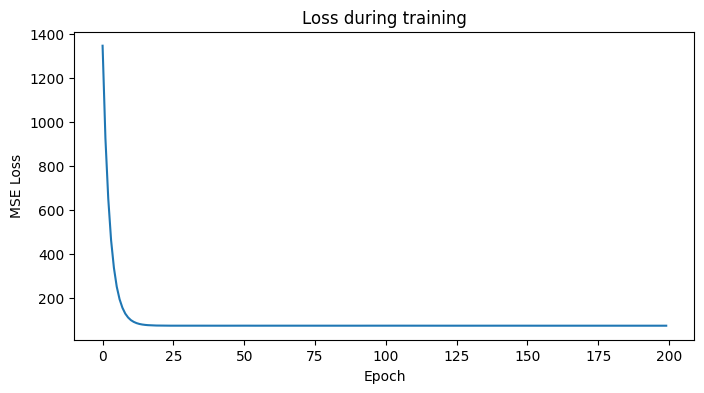

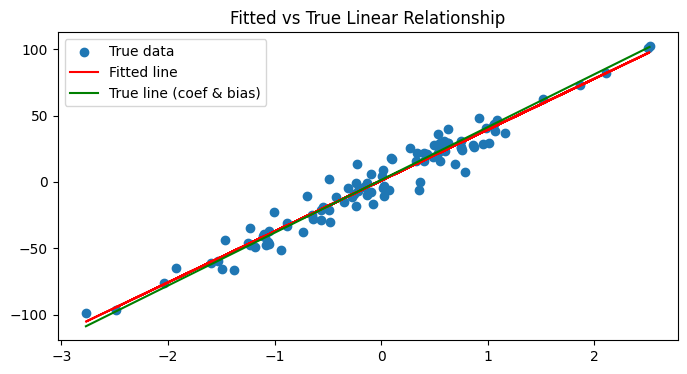

Learned weight: 38.366973876953125
Learned bias: 1.0218827724456787
True coef: 39.80551570183919


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1. 生成数据，coef就是w
x, y, coef = make_regression(n_samples=100, n_features=1, noise=10, bias=1.5, coef=True, random_state=22)
x = x.astype('float32')
y = y.astype('float32').reshape(-1, 1)

from torch.utils.data import TensorDataset, DataLoader

# 创建Dataset对象
dataset = TensorDataset(torch.from_numpy(x), torch.from_numpy(y))

# 创建DataLoader对象，batch_size=10
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

# 转为torch tensor
X = torch.from_numpy(x)
Y = torch.from_numpy(y)

# 2. 模型搭建（单层Linear层）
model = nn.Linear(1, 1)

# 3. 损失函数与优化器
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 为什么全梯度下降，比mini-batch损失下降的更慢
# 
# 1. **全梯度下降（Batch Gradient Descent）** 每次参数更新都需要遍历全部的训练数据，计算完整的梯度。
#    这导致每一次权重更新都很慢，特别是在数据量较大时，每次epoch的耗时很长。
#    此外，由于每次都用全部数据，模型参数的更新方向每次都很“稳定”，可能会卡在某些平坦区域，收敛速度慢。
#
# 2. **Mini-batch（小批量梯度下降）** 则是每次用一个小批数据计算梯度和更新参数。
#    Mini-batch 这种方式，参数更新更频繁，收敛过程更“跳跃”，可以更快地逃脱平坦区甚至局部最优。
#    同时，由于小批量带来的噪声，更新具有一定“随机性”，这在实际优化过程中有助于模型以更快速度取得优化效果。
#
# 3. 总结：
#    - 全梯度下降每次迭代很慢，更新方向单一；
#    - Mini-batch 更新快，方向多样，有利于加速收敛。
#    - Mini-batch 结合了全梯度和随机梯度的优点，因此损失下降更快。

# 4. 训练模型
losses = []
for epoch in range(200):
    epoch_loss = 0.0    # 用于累计本轮总损失
    for xb, yb in dataloader:  # 对DataLoader中每个batch进行训练
        y_pred = model(xb)                # 前向传播
        loss = criterion(y_pred, yb)      # 计算损失
        optimizer.zero_grad()             # 梯度清零
        loss.backward()                   # 反向传播
        optimizer.step()                  # 更新参数
        epoch_loss += loss.item() * xb.shape[0]  # 加权累计损失
    losses.append(epoch_loss / len(X))           # 记录每轮平均损失

# 5. 可视化结果
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title('Loss during training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# 同时绘制拟合的红线和真实的绿色线
plt.figure(figsize=(8,4))
plt.scatter(X.numpy(), Y.numpy(), label='True data')
with torch.no_grad():
    y_fit = model(X).numpy()
# 拟合结果（红线）
plt.plot(X.numpy(), y_fit, color='red', label='Fitted line')
# 真实直线（绿线）
x_sorted = X.numpy().flatten()
sort_idx = x_sorted.argsort()
x_sorted = x_sorted[sort_idx]
y_true = coef * x_sorted + 1.5
plt.plot(x_sorted, y_true, color='green', label='True line (coef & bias)')
plt.title('Fitted vs True Linear Relationship')
plt.legend()
plt.show()

# 打印模型参数
print("Learned weight:", model.weight.item())
print("Learned bias:", model.bias.item())
print("True coef:", coef)

# Dataset

In [16]:
# 自定义Dataset
import torch
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self):
        # 1. 初始化数据，例如读取文件
        self.data = ['李云龙','楚云飞','赵刚','丁伟','孔捷','常乃超','魏大勇','秀芹']
        self.total = len(self.data)
        
    def __getitem__(self, index):
        # 2. 获取索引对应的数据，就是返回某一个样本
        return self.data[index]
    
    
    def __len__(self):
        # 3. 返回数据集的长度,就是样本个数
        return self.total

if __name__ == '__main__':
    dataset = MyDataset()
    print(dataset[0])

李云龙


In [18]:
# DataLoader的创建
import torch
from torch.utils.data import DataLoader

# 创建DataLoader
# batch_size: 每次批次的大小
# shuffle: 是否打乱数据
dataloader = DataLoader(MyDataset(), batch_size=2, shuffle=True)

# 获取批次数据
for data in dataloader:
    print(data)

['常乃超', '秀芹']
['楚云飞', '孔捷']
['魏大勇', '赵刚']
['李云龙', '丁伟']
